# PandasAI Quickstart Guide

This notebook demonstrates how to get started with PandasAI and how to use it to analyze data through natural language.

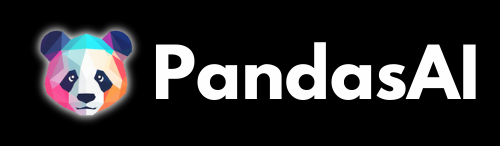


In [ ]:
# Importing the required libraries
import pandas as pd
import pandasai as pai
#from pandasai_litellm.litellm import LiteLLM
from pandasai_openai import OpenAI
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
from IPython.display import Image, display

In [ ]:
# Load environment variables
load_dotenv()

True

# 1. Getting Familiar with PandasAI
This section will cover the basics of PandasAI, such as loading data and using the .chat() method to talk to it.

## Read Database Directly
For this example, we will load our data directly from our Postgres database using SQLAlquemy 

In [3]:
# Get values from .env
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

In [8]:
# Create connection to Postgres
print(DB_HOST)
engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}?sslmode=require")



dpg-d35pib0dl3ps7394mc4g-a.oregon-postgres.render.com


In [6]:
# Connect to Postgres
query = "SELECT * FROM users LIMIT 1000;"

# Load data into pandas
database_df = pd.read_sql(query, engine)
print("Data loaded from Postgres")

database_df.head()

Data loaded from Postgres


,user_id,signup_date,country,device_type
0,1,2024-06-02,Rest,iOS
1,2,2024-03-20,India,Android
2,3,2023-09-17,EU,Web
3,4,2024-02-05,India,iOS
4,5,2025-06-08,India,Web


## Set up LLM

Use `pandasai_litellm` to select the LLM of your choice and use PandasAI

In [4]:
# Initialize LiteLLM with an OpenAI model
#llm = LiteLLM(model="gpt-4.1-mini")

# Use Open AI Model Instead
llm = OpenAI(api_token=os.getenv("OPEN_AI_API_KEY"))
# Configure PandasAI to use this LLM
pai.config.set({
    "llm": llm
})

## Chat with your data
Now we will use the .chat() method to chat with our data

In [8]:
# Convert our normal pandas dataframe to a pandasai dataframe
database_df = pai.DataFrame(database_df)

In [9]:
# Chat with the dataframe
response = database_df.chat("What is the most popular device type per country?")
print(response)

  country device_type  device_count
0      EU         Web            65
1   India         Web            67
2    Rest         iOS            78
3      US         iOS           142


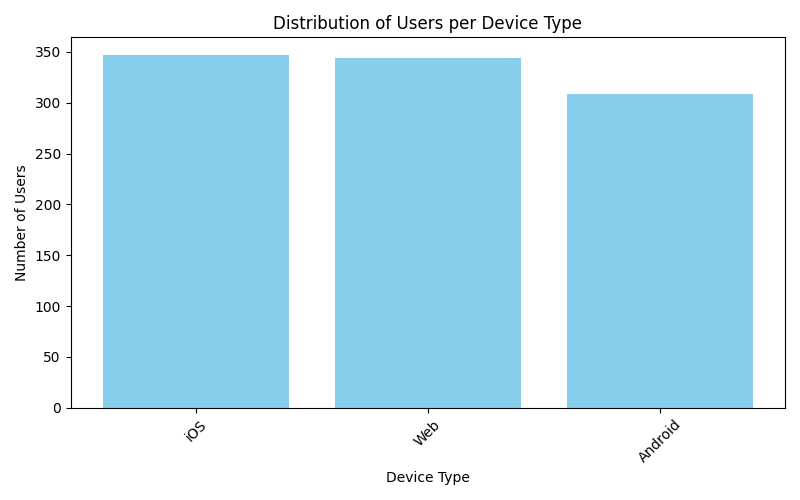

In [10]:
response = database_df.chat("Plot a bar chart showing the distribution of users per device type")

# Extract the path from ChartResponse object
chart_path = response.path if hasattr(response, 'path') else str(response)

# Display the chart with IPython display
display(Image(filename=chart_path))

In [11]:
# Chat with the dataframe
response = database_df.chat("[Ask your question here]")
print(response)

exports/charts/temp_chart_7fb8525a-c065-4cc6-a8f6-2efea4657919.png


## Read Database using PandasAI DB Data Extensions

Now we will learn how to load our data from our Postgres database using the .create() method. This will also create a dataset (locally) which can be reloaded in the future.

In [12]:
# Create a dataset once from the users table which can be reused anytime.
users_dataset = pai.create(

    # Format: "organization/dataset"
    path="public/users2",
    
    # Description of the dataset
    description="Users table from PostgreSQL database",

    # Source of our data (in this case a PostgreSQL table called users)
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },
        "table": "users"
    }
)

ValueError: Dataset already exists at path: public/users2

In [ ]:
# Chat with the dataframe
response = users_dataset.chat("What is the most popular device type per country?")
print(response)

  country device_type  device_count
0      EU         Web          1344
1   India         Web          1354
2    Rest         Web          1348
3      US         iOS          2723


## Load Dataset
After creation you load your datasets anytime with the following code

In [13]:
# Load the dataset we created in the previous step using the .create() method
dataset = pai.load("public/users")

Dataset loaded successfully.


# 2. Using a Semantic Layer in PandasAI
In this section, we will explore how to use a semantic layer in PandasAI in order to improve the accuracy of the AI agent.

## Adding Column Information

In [ ]:
# Create a dataset once from the subscriptions table which can be reused anytime.
subscriptions_dataset = pai.create(

    # Format: "organization/dataset"
    path="public/subscriptions2",
    
    # Description of the dataset
    description="Tracks user subscriptions to different plans",

    # Source of our data (in this case a PostgreSQL table called subscriptions)
    source={
        "type": "postgres",
        "connection": {
            "host": DB_HOST,
            "port": 5432,
            "user": DB_USER,
            "password": DB_PASS,
            "database": DB_NAME
        },
        "table": "subscriptions",

        # Define the structure and metadata of your dataset's columns.
        # If not provided, all columns from the input dataframe will be included.
        "columns": [
            {
                "name": "subscription_id",
                "type": "integer",
                "description": "Unique identifier for the subscription"
            },
            {
                "name": "user_id",
                "type": "integer",
                "description": "Foreign key linking to the users table"
            },
            {
                "name": "plan",
                "type": "string",
                "description": "The subscription plan (e.g., free, monthly, annual)"
            },
            {
                "name": "start_date",
                "type": "datetime",
                "description": "Date when the subscription started"
            },
            {
                "name": "end_date",
                "type": "datetime",
                "description": "Date when the subscription ended (if applicable)"
            },
            {
                "name": "status",
                "type": "string",
                "description": "Current status of the subscription (e.g., active, canceled, expired)"
            }
        ]
    }
)

Dataset saved successfully to path: public/subscriptions2


## Enhancing Your Semantic Layer

The semantic layer you just created can be further enhanced with additional features to improve AI accuracy and data understanding:

### What else can you add?

- **Column Expressions**: Define calculated/derived columns using formulas (e.g., `total_revenue = transaction_amount * (1 + tax_rate)`)
- **Column Aliases**: Create alternative names for columns to improve natural language understanding
- **Transformations**: Apply data transformations like anonymization or timezone conversion
- **Group By**: Specify which columns can be used for grouping operations

### How to add them?

These features must be added by **editing the schema.yaml file directly** in `datasets/public/subscriptions/schema.yaml`. 

For example, to add an alias and expression:
```yaml
columns:
  - name: plan
    type: string
    description: The subscription plan
    alias: subscription_plan  # Alternative name
  - name: subscription_length_days
    type: integer
    description: Length of subscription in days
    expression: "EXTRACT(DAY FROM (COALESCE(end_date, CURRENT_DATE) - start_date))"  # Calculated column
```

For detailed documentation on building a comprehensive semantic layer, including examples of expressions, aliases, transformations, and group_by configurations, visit:

📚 **[PandasAI Semantic Layer Documentation](https://docs.pandas-ai.com/v3/semantic-layer/new)**

This will help you create a more powerful and accurate AI agent that better understands your data and business logic.

In [ ]:
query = "SELECT * FROM telegram_messages"
engine2 = create_engine("sqlite:///db/telegram_channels.db")

database_df2 = pd.read_sql(query, engine2)
database_df2["message_date"] = pd.to_datetime(
    database_df2["message_date"],
    format="ISO8601",
    utc=True
)
database_df2["message_ts"] = database_df2["message_date"].astype("int64")
database_df2 = pai.DataFrame(database_df2)
database_df2.tail()

,channel_username,channel_title,message_id,message_date,message_text,scraped_at,message_hour,message_month,message_year,message_minute,message_dateFormatted,message_time,tagged_entities,entity_json,message_ts
105541,warmonitors,War Monitor,41733,2026-03-11 00:37:45+00:00,⚡️Hezbollah announced that they conducted 36 d...,2026-03-11T04:06:01.617053+00:00,0,3,2026,37,2026-03-11,00:37:45,"36 (CARDINAL), Israel (GPE), today (DATE)","[{""text"": ""36"", ""label"": ""CARDINAL""}, {""text"":...",1773189465000000000
105542,warmonitors,War Monitor,41732,2026-03-11 00:37:45+00:00,“How would you know”.\n\nHow can I say this in...,2026-03-11T04:06:01.617053+00:00,0,3,2026,37,2026-03-11,00:37:45,"Israel (GPE), 2014 (DATE), Israeli (NORP), doz...","[{""text"": ""Israel"", ""label"": ""GPE""}, {""text"": ...",1773189465000000000
105543,warmonitors,War Monitor,41731,2026-03-11 00:32:45+00:00,⚡️Renewed airstrikes on Tehran,2026-03-11T04:06:01.617053+00:00,0,3,2026,32,2026-03-11,00:32:45,Tehran (GPE),"[{""text"": ""Tehran"", ""label"": ""GPE""}]",1773189165000000000
105544,warmonitors,War Monitor,41730,2026-03-11 00:17:44+00:00,"No, Tel Aviv is not destroyed. \n\n99% of news...",2026-03-11T04:06:01.617053+00:00,0,3,2026,17,2026-03-11,00:17:44,"Tel Aviv (GPE), 99% (PERCENT), AI (GPE), Israe...","[{""text"": ""Tel Aviv"", ""label"": ""GPE""}, {""text""...",1773188264000000000
105545,warmonitors,War Monitor,41729,2026-03-11 00:12:45+00:00,⚡️Martyred Lebanese civilians in the Israeli a...,2026-03-11T04:06:01.617053+00:00,0,3,2026,12,2026-03-11,00:12:45,"Lebanese (NORP), Israeli (NORP), Shahabiya (GPE)","[{""text"": ""Lebanese"", ""label"": ""NORP""}, {""text...",1773187965000000000


In [10]:
from pandasai import Agent
agent = Agent(database_df2)

In [41]:
database_df2["message_date"] = pd.to_datetime(database_df2["message_date"], utc=True, errors="coerce")

response = agent.chat(
    """
Use message_date as the timestamp column and message_text as the text column.

Filter rows where message_date is on or after 2026-02-28.

The channel_title field contains the user handle of the channel's admin. message_text is the content of news alerts and updates

How many rows say impact or explosion? Attempt to glean the location from the message_text. 
If the location can't be gleaned, then use 'location unknown'. Group the count of rows by location.
"""
)
print(response)

           location  count
0  location unknown   1505
1              Iran    723
2           Bahrain    405
3               USA    390
4            Israel    227
5            Kuwait    207
6             Haifa     87
7         Palestine     42
8           Galilee     22


In [15]:
chan = "wc_israel"
response = agent.chat(f"""
                Can you review the message_text column for the channel_username labeled {chan}
                and estimate the channel's ideological leanings, who they 
                sympathize with, and who they perceive as enemies?
                They may use sarcasm or cynical names to express their dislike of those they perceive
                as enemies. Return a summary of your analysis for {chan}?.
                """)
print(response)

The channel appears to have a pro-Israel / Zionist ideological leaning. They sympathize primarily with Israel / Zionist groups. They perceive their enemies as Palestinian resistance groups such as Hamas, Iran-backed militias, and sometimes the USA's adversaries.. Use of sarcasm or cynical names is present to express dislike towards perceived enemies.


In [112]:
database_df2.info()

<class 'pandasai.dataframe.base.DataFrame'>
RangeIndex: 105546 entries, 0 to 105545
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   channel_username       105546 non-null  object             
 1   channel_title          105546 non-null  object             
 2   message_id             105546 non-null  int64              
 3   message_date           105546 non-null  datetime64[ns, UTC]
 4   message_text           105251 non-null  object             
 5   scraped_at             105546 non-null  object             
 6   message_hour           105546 non-null  object             
 7   message_month          105546 non-null  object             
 8   message_year           105546 non-null  object             
 9   message_minute         105546 non-null  object             
 10  message_dateFormatted  105546 non-null  object             
 11  message_time           105546 non

In [ ]:
"""database_df2["message_hour"] = database_df2["message_date"].dt.hour
database_df2["message_month"] = database_df2["message_date"].dt.month
database_df2["message_year"] = database_df2["message_date"].dt.year
database_df2["message_minute"] = database_df2["message_date"].dt.minute
database_df2["message_dateFormatted"] = database_df2["message_date"].dt.date
database_df2["message_time"] = database_df2["message_date"].dt.time"""

In [50]:
import json
import pandas as pd
import spacy

# Load spaCy model
nlp = spacy.load("en_core_web_sm", disable=["tagger", "parser", "lemmatizer"])

# Add custom EntityRuler BEFORE ner so your custom entities are included
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
else:
    ruler = nlp.get_pipe("entity_ruler")

patterns = [
    # Countries / places
    {"label": "GPE", "pattern": "Israel"},
    {"label": "GPE", "pattern": "Iran"},
    {"label": "GPE", "pattern": "Bahrain"},
    {"label": "GPE", "pattern": "Kuwait"},
    {"label": "GPE", "pattern": "Lebanon"},
    {"label": "GPE", "pattern": "Gaza"},
    {"label": "GPE", "pattern": "Tel Aviv"},
    {"label": "GPE", "pattern": "Jerusalem"},
    {"label": "GPE", "pattern": "Haifa"},
    {"label": "GPE", "pattern": "Tehran"},

    # Orgs / actors
    {"label": "ORG", "pattern": "IDF"},
    {"label": "ORG", "pattern": "IRGC"},
    {"label": "ORG", "pattern": "CENTCOM"},
    {"label": "ORG", "pattern": "Hezbollah"},
    {"label": "ORG", "pattern": "Hamas"},
    {"label": "ORG", "pattern": "Houthis"},

    # Weapons / systems
    {"label": "WEAPON", "pattern": "Shahed"},
    {"label": "WEAPON", "pattern": "Shahed drone"},
    {"label": "WEAPON", "pattern": "ballistic missile"},
    {"label": "WEAPON", "pattern": "cruise missile"},
    {"label": "WEAPON", "pattern": "drone"},
    {"label": "WEAPON", "pattern": "UAV"},
    {"label": "SYSTEM", "pattern": "Iron Dome"},
    {"label": "SYSTEM", "pattern": "Arrow"},
    {"label": "SYSTEM", "pattern": "David's Sling"},
]

ruler.add_patterns(patterns)

def extract_entities_from_doc(doc):
    entities = []
    seen = set()

    for ent in doc.ents:
        text = ent.text.strip()
        label = ent.label_
        key = (text.lower(), label)

        if text and key not in seen:
            seen.add(key)
            entities.append({"text": text, "label": label})

    tagged_entities = ", ".join(f'{e["text"]} ({e["label"]})' for e in entities) if entities else None
    entity_json = json.dumps(entities, ensure_ascii=False) if entities else None

    return tagged_entities, entity_json


def tag_dataframe_entities(df, text_col="message_text", batch_size=500):
    texts = df[text_col].fillna("").astype(str).tolist()

    tagged_entities = []
    entity_json = []

    for i, doc in enumerate(nlp.pipe(texts, batch_size=batch_size)):
        tagged, ent_json = extract_entities_from_doc(doc)
        tagged_entities.append(tagged)
        entity_json.append(ent_json)

        if i % 5000 == 0 and i > 0:
            print(f"Processed {i} rows")

    df = database_df2.copy()
    df["tagged_entities"] = tagged_entities
    df["entity_json"] = entity_json
    return df

In [51]:
database_df2 = tag_dataframe_entities(database_df2, text_col="message_text", batch_size=500)

Processed 5000 rows
Processed 10000 rows
Processed 15000 rows
Processed 20000 rows
Processed 25000 rows
Processed 30000 rows
Processed 35000 rows
Processed 40000 rows
Processed 45000 rows
Processed 50000 rows
Processed 55000 rows
Processed 60000 rows
Processed 65000 rows
Processed 70000 rows
Processed 75000 rows
Processed 80000 rows
Processed 85000 rows
Processed 90000 rows
Processed 95000 rows
Processed 100000 rows


In [116]:
df = database_df2.copy()

event_pattern = (
    r"\b("
    r"impact|hit|strike|struck|interception|intercepted|"
    r"sirens?|explosion|explosions|drone|missile|rocket|launch|launched"
    r")\b"
)

df["is_event"] = df["message_text"].fillna("").str.contains(
    event_pattern,
    case=False,
    regex=True
)

/var/folders/n_/wz1xml0d2xxd4_8c9g324j_c0000gn/T/ipykernel_32112/1456280004.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_event"] = df["message_text"].fillna("").str.contains(


In [117]:
events = df[df["is_event"]].copy()
events = events.sort_values("message_date").reset_index(drop=True)

In [118]:
events["time_diff_seconds"] = events["message_date"].diff().dt.total_seconds()

events["new_cluster"] = (
    events["time_diff_seconds"].isna() |
    (events["time_diff_seconds"] > 30)
)

events["event_cluster_id"] = events["new_cluster"].cumsum()

In [119]:
cluster_summary = (
    events.groupby("event_cluster_id")
    .agg(
        cluster_start=("message_date", "min"),
        cluster_end=("message_date", "max"),
        message_count=("message_id", "count"),
        channels=("channel_username", lambda x: ", ".join(sorted(set(x)))),
        channel_count=("channel_username", lambda x: x.nunique()),
        sample_text=("message_text", "first"),
        entities=("tagged_entities", lambda x: ", ".join(sorted(set(v for v in x.dropna() if v))))
    )
    .reset_index()
)

cluster_summary["duration_seconds"] = (
    cluster_summary["cluster_end"] - cluster_summary["cluster_start"]
).dt.total_seconds()

In [120]:
cluster_summary

,event_cluster_id,cluster_start,cluster_end,message_count,channels,channel_count,sample_text,entities,duration_seconds
0,1,2026-01-01 01:01:54+00:00,2026-01-01 01:01:54+00:00,1,OSINTWarfare,1,Ukrainian kamikaze drones struck the Ilsky oil...,"Ukrainian (NORP), Ilsky (ORG), Krasnodar Krai ...",0.0
1,2,2026-01-01 07:11:26+00:00,2026-01-01 07:11:26+00:00,1,hnaftali,1,**Ynet News: The only Israeli UAV operator fly...,"Israeli (NORP), UAV (WEAPON), Gaza (GPE), Hama...",0.0
2,3,2026-01-01 11:18:02+00:00,2026-01-01 11:18:03+00:00,2,warmonitors,1,⚡Al-Manar correspondent:\n\nAn Israeli enemy f...,"Al-Manar (PERSON), Israeli (NORP), Lebanese (N...",1.0
3,4,2026-01-01 11:25:47+00:00,2026-01-01 11:25:47+00:00,1,thecradlemedia,1,**❗️Israel strips Hebron municipality of autho...,"Hebron (GPE), Ibrahimi Mosque (PERSON), Israel...",0.0
4,5,2026-01-01 12:31:38+00:00,2026-01-01 12:31:38+00:00,1,kalibrated,1,Multiple Ukrainian drones struck a cafe in the...,"Khorly (GPE), Russian (NORP), Kherson Oblast (...",0.0
...,...,...,...,...,...,...,...,...,...
11716,11717,2026-03-11 03:51:44+00:00,2026-03-11 03:51:45+00:00,2,"me_observer_TG, tabzlive",2,**🇮🇱****❌****🇱🇧**** — NEW:** An Israeli airstr...,"Israeli (NORP), Aisha Bakar (PERSON), Beirut (...",1.0
11717,11718,2026-03-11 03:53:08+00:00,2026-03-11 03:53:08+00:00,1,wfwitness,1,⚡️🇱🇧🇮🇱 Additional footage from Beirut followin...,"🇮🇱 Additional (PERSON), Beirut (GPE), Israeli ...",0.0
11718,11719,2026-03-11 03:54:05+00:00,2026-03-11 03:54:05+00:00,1,me_observer_TG,1,⚡️ 🔺US sources: The Trump administration made ...,"US (GPE), Trump (PERSON), Iran (GPE), The New ...",0.0
11719,11720,2026-03-11 03:59:48+00:00,2026-03-11 03:59:48+00:00,1,RezistanceTrench1,1,🇺🇸 🇮🇱 BOEING secures contract to supply Israel...,"🇸 (PERSON), 🇮 (CARDINAL), BOEING (ORG), Israel...",0.0


In [121]:
high_signal_clusters = cluster_summary[
    cluster_summary["channel_count"] >= 2
].copy()

In [123]:
import pandas as pd

df = database_df2.copy()

event_pattern = (
    r"\b("
    r"impact|hit|strike|struck|interception|intercepted|"
    r"sirens?|explosion|explosions|drone|missile|rocket|launch|launched"
    r")\b"
)

df["is_event"] = df["message_text"].fillna("").str.contains(
    event_pattern,
    case=False,
    regex=True
)

def classify_event(text):
    text = str(text).lower()

    if "intercept" in text:
        return "interception"
    if "siren" in text:
        return "siren"
    if "impact" in text or "hit" in text or "strike" in text or "struck" in text:
        return "impact"
    if "launch" in text:
        return "launch"
    if "explosion" in text:
        return "explosion"
    if "drone" in text or "missile" in text or "rocket" in text:
        return "projectile"
    return "other"

events = df[df["is_event"]].copy()
events["event_type"] = events["message_text"].apply(classify_event)

events = events.sort_values(["event_type", "message_date"]).reset_index(drop=True)

events["time_diff_seconds"] = (
    events.groupby("event_type")["message_date"]
    .diff()
    .dt.total_seconds()
)

events["new_cluster"] = (
    events["time_diff_seconds"].isna() |
    (events["time_diff_seconds"] > 30)
)

events["cluster_num"] = (
    events.groupby("event_type")["new_cluster"].cumsum()
)

events["event_cluster_id"] = (
    events["event_type"] + "_" + events["cluster_num"].astype(str)
)

cluster_summary = (
    events.groupby(["event_cluster_id", "event_type"])
    .agg(
        cluster_start=("message_date", "min"),
        cluster_end=("message_date", "max"),
        message_count=("message_id", "count"),
        channels=("channel_username", lambda x: ", ".join(sorted(set(x)))),
        channel_count=("channel_username", "nunique"),
        sample_text=("message_text", "first"),
        entities=("tagged_entities", lambda x: ", ".join(sorted(set(v for v in x.dropna() if v))))
    )
    .reset_index()
)

cluster_summary["duration_seconds"] = (
    cluster_summary["cluster_end"] - cluster_summary["cluster_start"]
).dt.total_seconds()

cluster_summary["severity_score"] = (
    cluster_summary["message_count"] + 2 * cluster_summary["channel_count"]
)

cluster_summary = cluster_summary.sort_values(
    ["severity_score", "cluster_start"],
    ascending=[False, False]
)

cluster_summary.head(20)

/var/folders/n_/wz1xml0d2xxd4_8c9g324j_c0000gn/T/ipykernel_32112/1143443706.py:12: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["is_event"] = df["message_text"].fillna("").str.contains(


,event_cluster_id,event_type,cluster_start,cluster_end,message_count,channels,channel_count,sample_text,entities,duration_seconds,severity_score
988,explosion_280,explosion,2026-02-28 09:07:18+00:00,2026-02-28 09:11:42+00:00,25,"CIG_telegram, ClashReport, DDGeopolitics, Fron...",17,⚡🇮🇷/🇮🇱🇺🇸 — IRAN-ISRAEL WAR: Explosions occured...,"Abu Dhabi (GPE), Abu Dhabi (GPE), UAE (GPE), A...",264.0,59
3218,impact_2288,impact,2026-02-28 21:02:01+00:00,2026-02-28 21:04:24+00:00,15,"CIG_telegram, DDGeopolitics, FrontlineReportNe...",12,🇮🇷❌🇧🇭❗️ — Footage of a building close to colla...,"At least one (CARDINAL), Iranian (NORP), balli...",143.0,39
3874,impact_2879,impact,2026-03-01 20:45:24+00:00,2026-03-01 20:47:55+00:00,13,"CIG_telegram, ClashReport, GeoPWatch, LebUpdat...",10,**⚡️****🇮🇷****🇮🇷****❌****🇮🇱****🇺🇸**** - Medica...,"IDF (ORG), Israelis (NORP), Iranian (NORP), Je...",151.0,33
3811,impact_2821,impact,2026-03-01 18:52:14+00:00,2026-03-01 18:54:09+00:00,13,"CIG_telegram, ClashReport, DDGeopolitics, Fotr...",9,French President Macron:\n\nThe missile and dr...,"560 (CARDINAL), US (GPE), one (CARDINAL), Amer...",115.0,31
3207,impact_2278,impact,2026-02-28 20:45:22+00:00,2026-02-28 20:47:12+00:00,11,"BellumActaNews, CIG_telegram, ClashReport, Fro...",9,🇮🇷🇮🇱⚡️- Another visual confirmation of an Iran...,"Iranian (NORP), Tel Aviv (GPE), Israel (GPE), ...",110.0,29
2761,impact_1877,impact,2026-02-28 09:34:59+00:00,2026-02-28 09:36:16+00:00,11,"AssyriaNewsNetwork, BellumActaNews, CIG_telegr...",9,🇺🇸🇮🇱❌🇮🇷 — IRGC's Imam Mahdi garrison in the ci...,"Abu Dhabi (GPE), INSANE (ORG), Iranian (NORP),...",77.0,29
4230,impact_3199,impact,2026-03-02 11:01:13+00:00,2026-03-02 11:02:56+00:00,10,"DDGeopolitics, RezistanceTrench1, SGTnewsNetwo...",9,BREAKING: Israel eliminated senior figures fro...,"Be (GPE), Sheba (GPE), Ben Gurion Airport (FAC...",103.0,28
16864,siren_46,siren,2026-02-28 09:07:19+00:00,2026-02-28 09:09:11+00:00,10,"BellumActaNews, CIG_telegram, FotrosResistance...",9,🇮🇱 War sirens are sounding throughout the enti...,"Ian (PERSON), UAE (GPE), Kuwait (GPE), Israel ...",112.0,28
2717,impact_1837,impact,2026-02-28 08:24:09+00:00,2026-02-28 08:26:11+00:00,10,"BellumActaNews, CIG_telegram, FotrosResistance...",9,**An Iranian missile has reportedly hit areas ...,"Haifa (GPE), Iran (GPE), 2 (CARDINAL), Iranian...",122.0,28
2743,impact_1860,impact,2026-02-28 09:06:38+00:00,2026-02-28 09:09:13+00:00,11,"BellumActaNews, ClashReport, GeoPWatch, intels...",8,What Has Happened so far in the Iran-US-Israel...,"Bahrain (GPE), American (NORP), Bahrain (GPE),...",155.0,27


In [138]:
from gdeltdoc import GdeltDoc, Filters

f = Filters(
    keyword = "breaking news",
    start_date = "2026-03-09",
    end_date = "2026-03-11"
)

gd = GdeltDoc()

# Search for articles matching the filters
articles = gd.article_search(f)

# Get a timeline of the number of articles matching the filters
#timeline = gd.timeline_search("timelinevol", f)
print(articles)

RateLimitError: 

In [137]:
articles.tail()

""


In [172]:
import requests
import pandas as pd

url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/1.0_day.geojson"

data = requests.get(url).json()

rows = []

for feature in data["features"]:
    
    props = feature["properties"]
    coords = feature["geometry"]["coordinates"]
    
    row = {
        "longitude": coords[0],
        "latitude": coords[1],
        "depth": coords[2],
        "magnitude": props["mag"],
        "title": props["title"],
        "location": props["place"],
        "type": props["type"],
        "time": pd.to_datetime(props["time"], unit="ms"),
        "epochTime": props["time"]
    }
    
    rows.append(row)

df = pd.DataFrame(rows)
df = df.sort_values("epochTime", ascending=True)
df['depth'] = df['depth'] * -1
df["secondsSinceLastEQ"] = (df["epochTime"] - df["epochTime"].shift())*0.001

print(df.head())

      longitude   latitude    depth  magnitude  \
223 -175.260900  50.585000 -10.0000       2.70   
222 -104.418000  31.646000  -5.4333       2.20   
221 -118.193000  38.183100  -9.3727       1.76   
220 -117.468900  37.639900  -5.9029       1.52   
219 -164.730167  54.563167 -18.4300       0.97   

                                          title  \
223          M 2.7 - 172 km SSE of Adak, Alaska   
222  M 2.2 - 58 km S of Whites City, New Mexico   
221           M 1.8 - 24 km SSW of Mina, Nevada   
220     M 1.5 - 19 km SE of Silver Peak, Nevada   
219          M 1.0 - 83 km NE of Akutan, Alaska   

                               location        type                    time  \
223          172 km SSE of Adak, Alaska  earthquake 2026-03-11 02:57:05.125   
222  58 km S of Whites City, New Mexico  earthquake 2026-03-11 03:01:17.613   
221           24 km SSW of Mina, Nevada  earthquake 2026-03-11 03:02:55.691   
220     19 km SE of Silver Peak, Nevada  earthquake 2026-03-11 03:03:09.764 

In [159]:
import plotly.express as px

fig = px.scatter_map(
    df,
    lat="latitude",
    lon="longitude",
    size="magnitude",
    hover_name="title",
    map_style= 'carto-darkmatter',
    zoom=1
)

fig.update_layout(
    width = 1200,
    height = 800
)
fig.show()

In [161]:
fig = px.scatter(df, x='time', y='depth',
                    size = 'magnitude',
                    hover_name = 'title')

fig.show()

In [173]:
fig = px.scatter(df, x='time', y='secondsSinceLastEQ',
                    size = 'magnitude',
                    hover_name = 'title')

fig.show()

In [163]:
fig = px.scatter(df, x='time', y='depth',
                    size = 'magnitude',
                    hover_name = 'title')

fig.show()

In [2]:
import sqlite3

db_path = "db/telegram_channels.db"
conn = sqlite3.connect(db_path)

conn.execute("PRAGMA wal_checkpoint(FULL);")
conn.execute("VACUUM;")
conn.execute("ANALYZE;")

conn.close()

In [13]:
import sqlite3
import pandas as pd

db_path = "db/telegram_channels.db"
conn = sqlite3.connect(db_path)
#r = conn.execute("PRAGMA table_info(telegram_cluster_metrics_recent);")
#query = "PRAGMA table_info(telegram_cluster_metrics_recent);"

query = "SELECT * FROM telegram_cluster_metrics_recent;"
r = pd.read_sql(query, conn)
print(r)
conn.close()

              event_cluster_id    event_type  geo_group    country  \
0             siren_tel_aviv_5         siren   tel_aviv     Israel   
1      interception_unknown_41  interception    unknown       None   
2             launch_Israel_33        launch     Israel     Israel   
3        projectile_unknown_69    projectile    unknown       None   
4                siren_eilat_1         siren      eilat     Israel   
...                        ...           ...        ...        ...   
2904        explosion_Israel_1     explosion     Israel     Israel   
2905       projectile_Israel_1    projectile     Israel     Israel   
2906  interception_Palestine_1  interception  Palestine  Palestine   
2907           siren_unknown_1         siren    unknown       None   
2908            siren_Israel_1         siren     Israel     Israel   

     location_key location_text              cluster_start  \
0        tel_aviv      tel aviv  2026-03-12 02:13:20+00:00   
1            None          None  20